# Datathon Pipeline (EDA + NaN + Optuna + Ensemble)
Incluye chequeo de MRE tipo Kaggle

In [1]:

import os, warnings, numpy as np, pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

from sklearn.model_selection import KFold
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor

import optuna
from optuna.samplers import TPESampler


In [2]:

# LOAD
base_path = Path(r"C:\Users\Sofi\OneDrive - Universidad de Montevideo\Documentos\Datathlon")
train = pd.read_csv(base_path / "train.csv")
test = pd.read_csv(base_path / "test.csv")

if "Unnamed: 0" in test.columns:
    test = test.rename(columns={"Unnamed: 0":"ID"})


## 📊 EDA básico

1. DIMENSIONES Y PRIMERA VISTA
Train shape: (40000, 25)
Test shape:  (10000, 24)

Primeras filas train:


,Unnamed: 0,vigente,vigenteAvg3M,vencido,vencidoAvg3M,avgcontingenciaU1M,avgcontingenciaU3M,sumcontingenciaU1M,sumcontingenciaU3M,maxcontingenciaU1M,...,numerobancosprivados,numerobancospublicos,numerofinancieras,numerobancos,numerode5ult18meses,numerode2Bult18meses,numerode3ult18meses,edad,numeromesesreportados,ingreso
0,1,4282.155183,4679.335952,0.000000,0.000000,4923.124484,3918.527125,19692.497937,18439.941778,6653.069810,...,1,0,3,1,0,0,0,63.0,24,31888.466530
1,2,9793.122650,9450.927278,83970.243387,91126.581200,20809.053382,19126.815664,41618.106764,49280.496926,30881.253937,...,0,1,1,1,4,0,2,67.0,24,62341.141710
2,3,531419.701556,512057.084981,0.000000,0.000000,36813.149453,46144.419161,36813.149453,36789.292777,36813.149453,...,2,1,0,3,0,0,0,NaN,24,100599.764680
3,4,0.000000,0.000000,2266.728708,2633.111538,11533.815438,10488.338604,23067.630876,24025.952782,19044.717097,...,4,0,0,4,4,2,3,NaN,24,46102.904895
4,5,112394.057367,110856.020945,0.000000,0.000000,41131.333850,42820.024254,82262.667700,77614.227322,43944.580379,...,4,0,0,4,0,0,0,65.0,14,109419.216020



Primeras filas test:


,ID,vigente,vigenteAvg3M,vencido,vencidoAvg3M,avgcontingenciaU1M,avgcontingenciaU3M,sumcontingenciaU1M,sumcontingenciaU3M,maxcontingenciaU1M,...,numeroinstituciones,numerobancosprivados,numerobancospublicos,numerofinancieras,numerobancos,numerode5ult18meses,numerode2Bult18meses,numerode3ult18meses,edad,numeromesesreportados
0,40001,10725.957382,11480.961340,0.0,0.0,19510.697566,23402.938295,19510.697566,20719.358643,19510.697566,...,2,0,0,2,0,0,3,0,29.0,24
1,40002,82242.277287,77710.508800,0.0,0.0,13968.618508,14816.095112,27937.237016,23324.599806,17527.530907,...,5,0,1,4,1,0,1,0,66.0,24
2,40003,1646.607555,1836.928522,0.0,0.0,71846.928147,68585.407866,71846.928147,83632.771011,71846.928147,...,2,2,0,0,2,0,4,0,35.0,24
3,40004,8740.977410,8640.764002,0.0,0.0,24560.879097,26136.018124,49121.758195,48865.156174,42492.834450,...,2,1,1,0,2,0,0,0,54.0,24
4,40005,365107.557629,366550.793336,0.0,0.0,13879.429839,11677.655495,27758.859677,28020.443219,23587.864067,...,2,1,1,0,2,0,1,0,NaN,19



2. INFO GENERAL

Tipos de datos train:
Unnamed: 0                 int64
vigente                  float64
vigenteAvg3M             float64
vencido                  float64
vencidoAvg3M             float64
avgcontingenciaU1M       float64
avgcontingenciaU3M       float64
sumcontingenciaU1M       float64
sumcontingenciaU3M       float64
maxcontingenciaU1M       float64
maxcontingenciaU3M       float64
numcontingenciaU1M         int64
garantiacomputable       float64
peorcalificacionBCU          str
numeroinstituciones        int64
numerobancosprivados       int64
numerobancospublicos       int64
numerofinancieras          int64
numerobancos               int64
numerode5ult18meses        int64
numerode2Bult18meses       int64
numerode3ult18meses        int64
edad                     float64
numeromesesreportados      int64
ingreso                  float64
dtype: object

Resumen info train:
<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 25 columns):
 #

...

,missing_count,missing_pct
edad,2802,28.02



5. RESUMEN ESTADISTICO


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,40000.0,NaN,NaN,NaN,20000.5,11547.14972,1.0,10000.75,20000.5,30000.25,40000.0
vigente,40000.0,NaN,NaN,NaN,180555.845581,1309327.125985,0.0,2714.869774,24827.977045,106775.404705,142856335.107241
vigenteAvg3M,40000.0,NaN,NaN,NaN,179008.479072,1197322.746959,0.0,2680.995263,24753.635089,106792.97076,114197324.622602
vencido,40000.0,NaN,NaN,NaN,53401.917628,500587.284959,0.0,0.0,0.0,79.683887,55026973.148005
vencidoAvg3M,40000.0,NaN,NaN,NaN,52701.808628,480357.115134,0.0,0.0,0.0,74.277831,52478502.025609
avgcontingenciaU1M,40000.0,NaN,NaN,NaN,28293.474478,40831.997899,0.0,5136.342946,15661.770868,35345.655474,1185965.472018
avgcontingenciaU3M,40000.0,NaN,NaN,NaN,28289.037655,41157.34037,0.0,5068.27968,15514.009131,35304.71576,1191323.936375
sumcontingenciaU1M,40000.0,NaN,NaN,NaN,55080.813247,58070.17828,0.0,20439.717018,39780.961066,71149.032977,1287908.610466
sumcontingenciaU3M,40000.0,NaN,NaN,NaN,55145.967899,58731.292079,0.0,20208.492688,39499.743281,71125.327163,1366562.591931
maxcontingenciaU1M,40000.0,NaN,NaN,NaN,41721.889337,48098.089467,0.0,12972.430061,28082.221617,54018.340758,1211490.637028



6. TARGET ANALYSIS
Resumen de ingreso:


count    4.000000e+04
mean     6.817205e+04
std      5.463311e+04
min      1.745280e+04
25%      3.790579e+04
50%      5.356258e+04
75%      8.072237e+04
max      3.316147e+06
Name: ingreso, dtype: float64

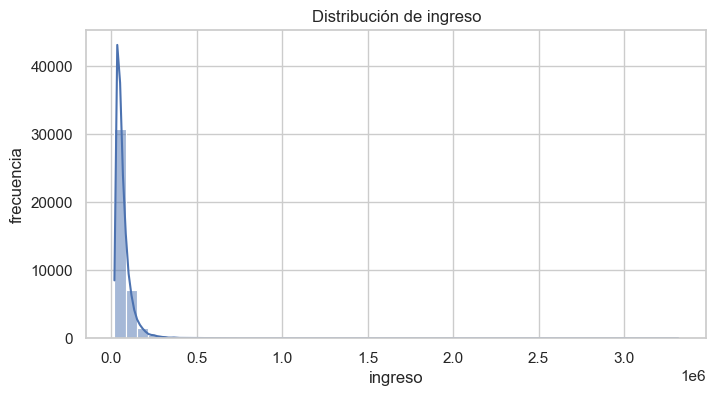

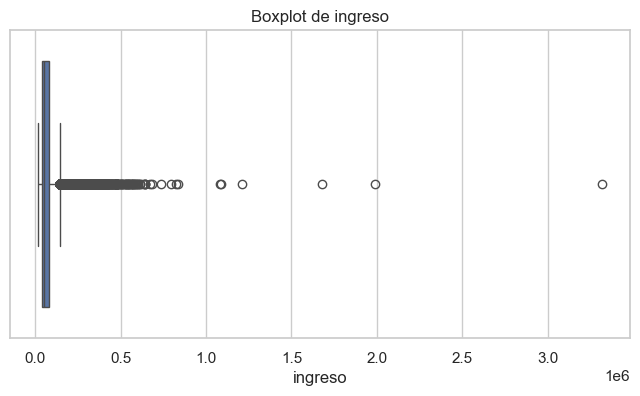

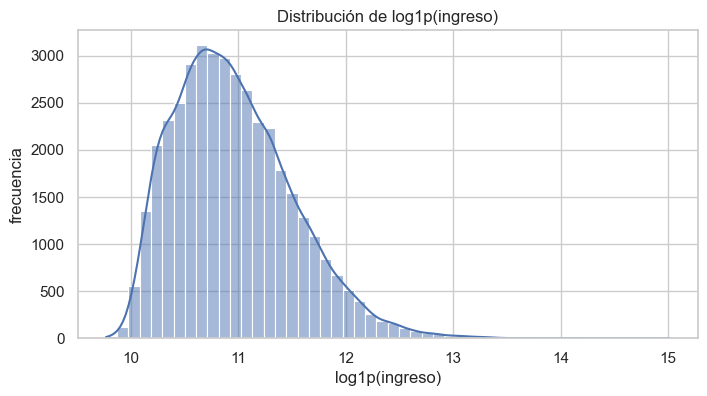


7. DETECCION DE COLUMNAS
Cantidad de columnas numéricas: 24
Cantidad de columnas categóricas: 1

Columnas categóricas:
['peorcalificacionBCU']

Columnas numéricas:
['Unnamed: 0', 'vigente', 'vigenteAvg3M', 'vencido', 'vencidoAvg3M', 'avgcontingenciaU1M', 'avgcontingenciaU3M', 'sumcontingenciaU1M', 'sumcontingenciaU3M', 'maxcontingenciaU1M', 'maxcontingenciaU3M', 'numcontingenciaU1M', 'garantiacomputable', 'numeroinstituciones', 'numerobancosprivados', 'numerobancospublicos', 'numerofinancieras', 'numerobancos', 'numerode5ult18meses', 'numerode2Bult18meses', 'numerode3ult18meses', 'edad', 'numeromesesreportados']

8. CARDINALIDAD DE CATEGORICAS


,n_unique,missing_count
peorcalificacionBCU,6,0



Top valores de peorcalificacionBCU:


peorcalificacionBCU
1C    27096
5      6435
3      2689
2A     1455
2B     1443
4       882
Name: count, dtype: int64


9. OUTLIERS EN NUMERICAS (IQR)


,column,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
4,vencidoAvg3M,0.000000,74.277831,74.277831,-111.416747,185.694579,9992,24.9800
3,vencido,0.000000,79.683887,79.683887,-119.525830,199.209717,9991,24.9775
18,numerode5ult18meses,0.000000,0.000000,0.000000,0.000000,0.000000,9986,24.9650
20,numerode3ult18meses,0.000000,0.000000,0.000000,0.000000,0.000000,9011,22.5275
22,numeromesesreportados,24.000000,24.000000,0.000000,24.000000,24.000000,8955,22.3875
19,numerode2Bult18meses,0.000000,1.000000,1.000000,-1.500000,2.500000,5277,13.1925
1,vigente,2714.869774,106775.404705,104060.534931,-153375.932623,262866.207102,5172,12.9300
2,vigenteAvg3M,2680.995263,106792.970760,104111.975497,-153486.967984,262960.934006,5147,12.8675
14,numerobancosprivados,0.000000,1.000000,1.000000,-1.500000,2.500000,3779,9.4475
12,garantiacomputable,0.000000,0.000000,0.000000,0.000000,0.000000,3550,8.8750



10. CORRELACION CON EL TARGET
Top correlaciones absolutas con ingreso:


maxcontingenciaU3M      0.763232
maxcontingenciaU1M      0.757676
sumcontingenciaU1M      0.702307
sumcontingenciaU3M      0.697830
avgcontingenciaU3M      0.664553
avgcontingenciaU1M      0.663202
garantiacomputable      0.415729
vigente                 0.413546
vigenteAvg3M            0.404555
vencidoAvg3M            0.140889
vencido                 0.140879
edad                    0.107560
numerobancosprivados    0.101844
numerofinancieras      -0.094296
numerobancos            0.077837
Name: ingreso, dtype: float64

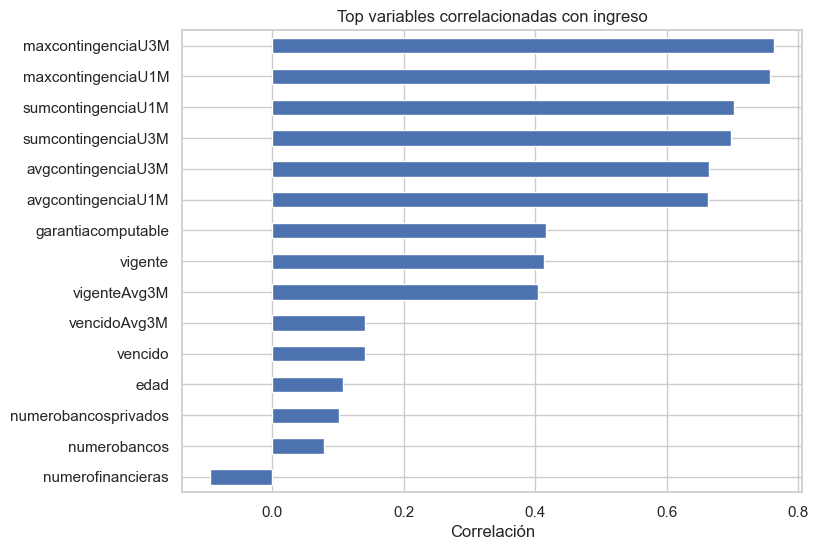


11. MATRIZ DE CORRELACION ENTRE NUMERICAS


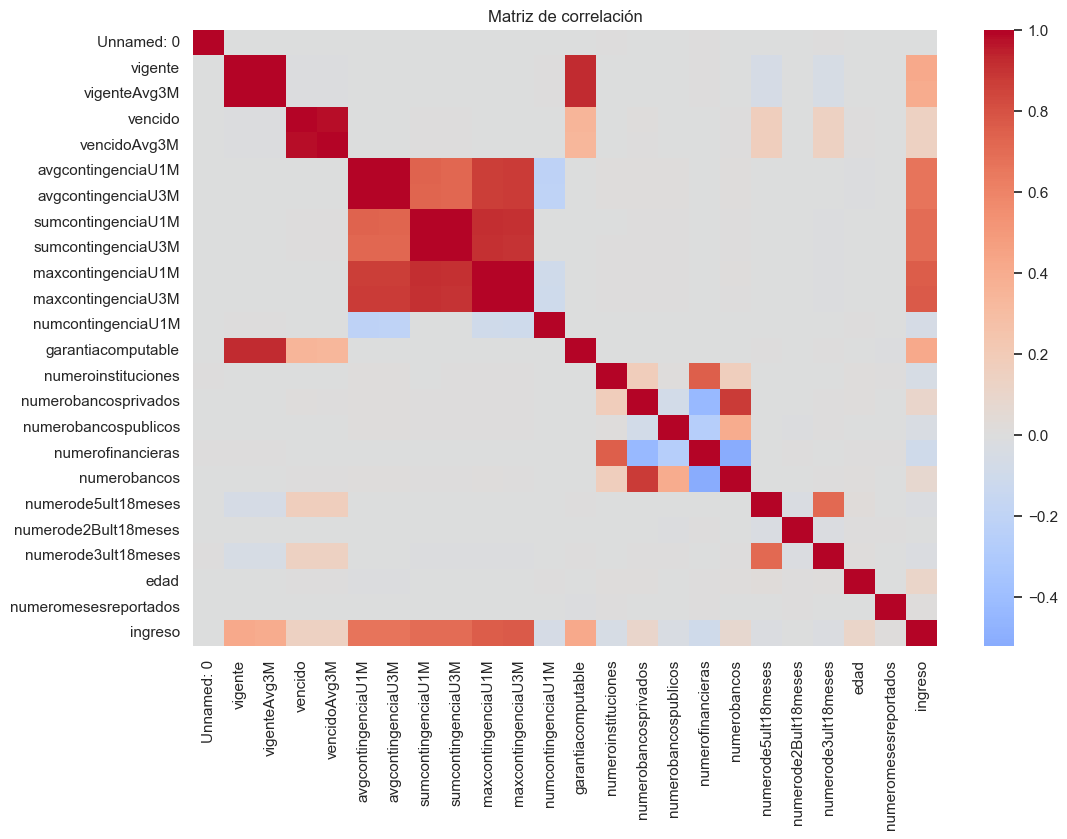


12. COMPARACION TRAIN VS TEST


,column,train_dtype,test_dtype,train_missing_pct,test_missing_pct,train_nunique,test_nunique
0,vigente,float64,float64,0.0,0.0,31914,8091
1,vigenteAvg3M,float64,float64,0.0,0.0,31914,8091
2,vencido,float64,float64,0.0,0.0,10007,2395
3,vencidoAvg3M,float64,float64,0.0,0.0,10007,2395
4,avgcontingenciaU1M,float64,float64,0.0,0.0,32389,8008
5,avgcontingenciaU3M,float64,float64,0.0,0.0,32389,8008
6,sumcontingenciaU1M,float64,float64,0.0,0.0,35969,8921
7,sumcontingenciaU3M,float64,float64,0.0,0.0,35969,8921
8,maxcontingenciaU1M,float64,float64,0.0,0.0,35969,8921
9,maxcontingenciaU3M,float64,float64,0.0,0.0,35969,8921



13. GRAFICOS DE VARIABLES NUMERICAS MAS RELACIONADAS CON INGRESO


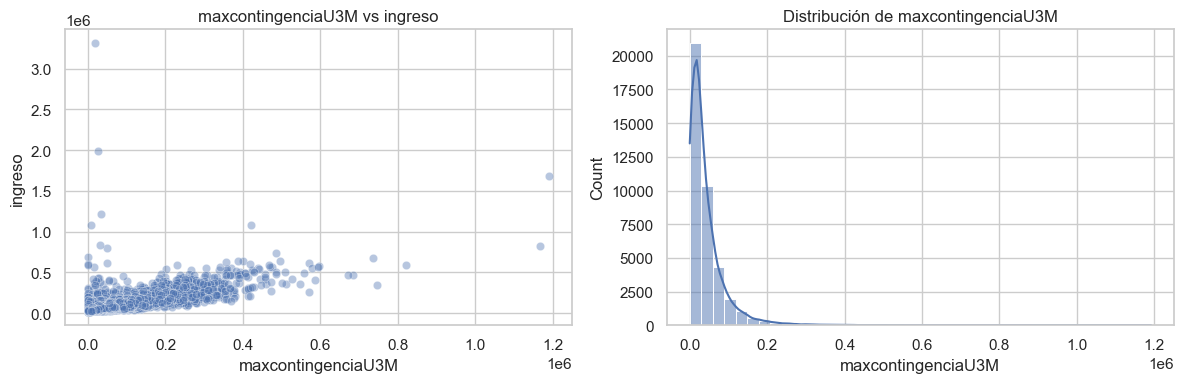

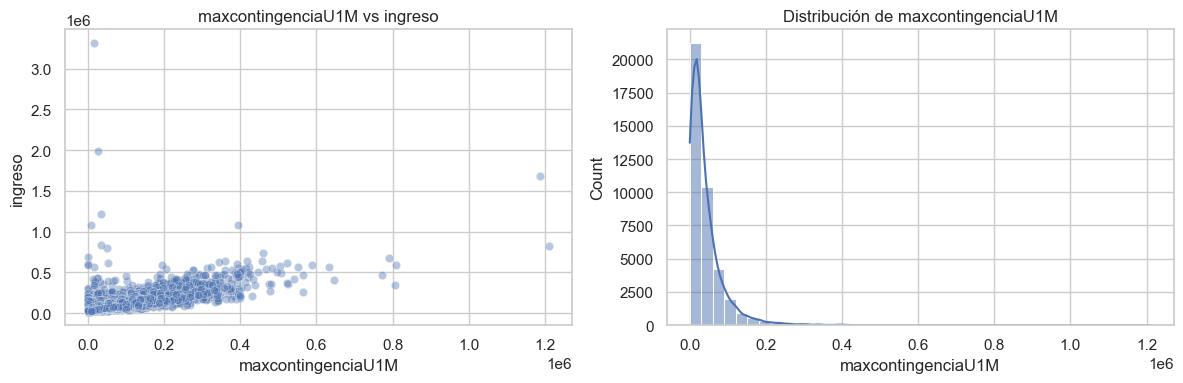

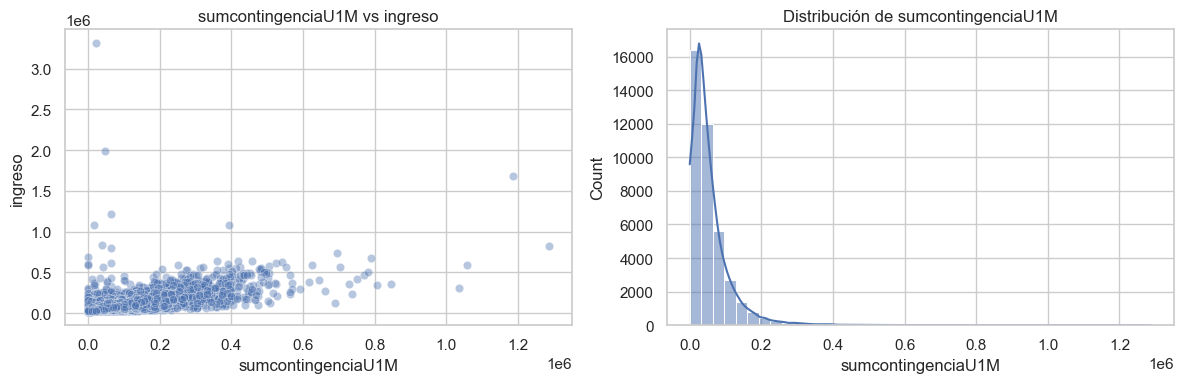

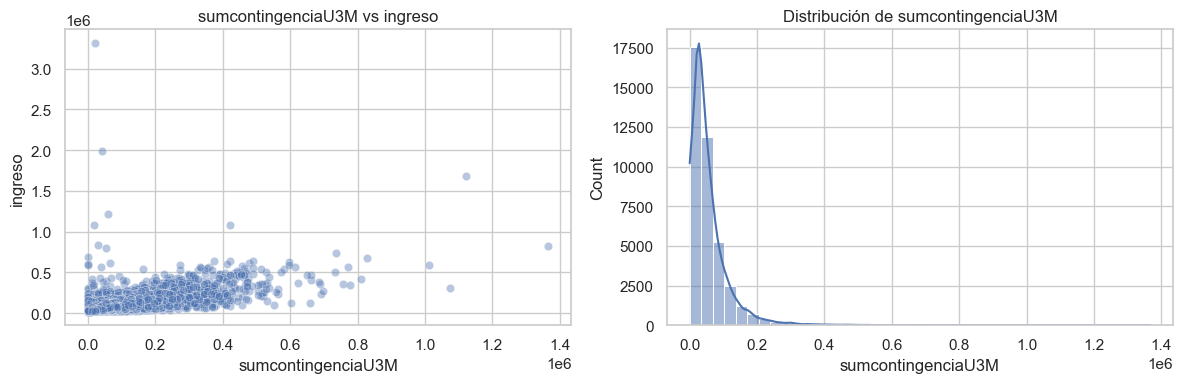

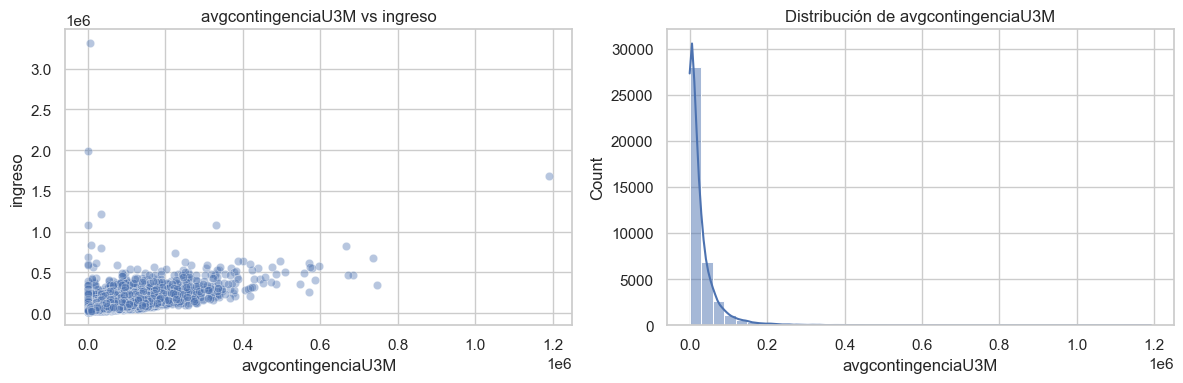

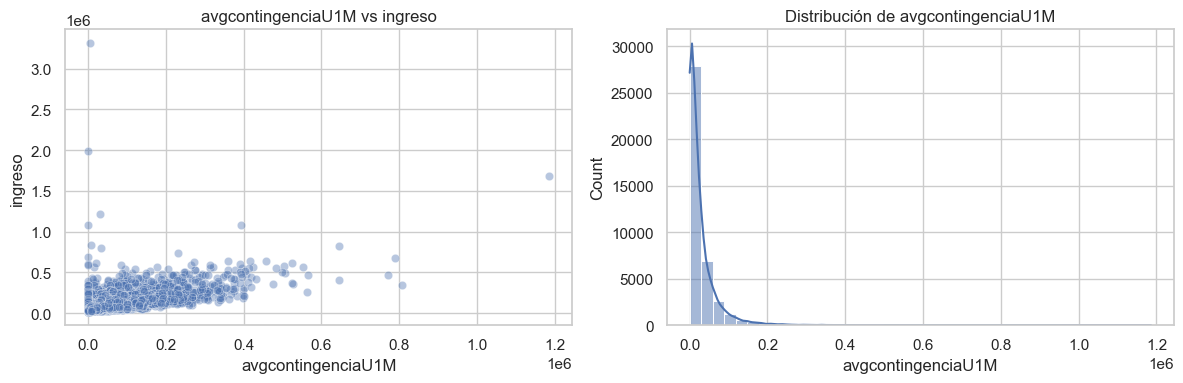


14. BOXPLOTS DE CATEGORICAS VS INGRESO


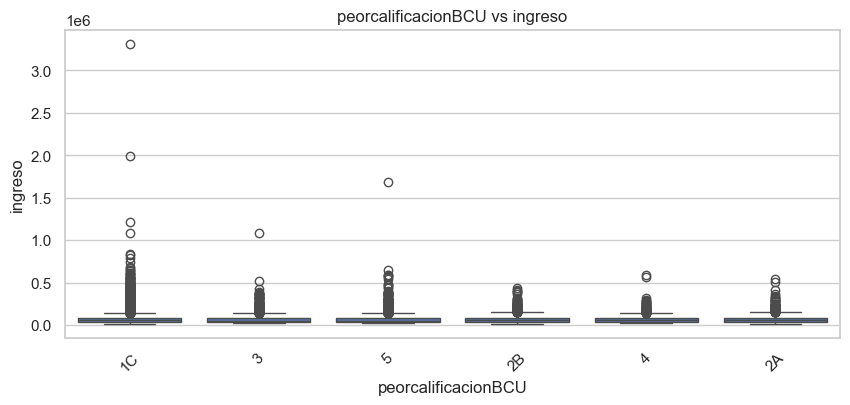


15. CHEQUEO FINAL PARA MODELADO
Columnas en train que no están en test:
['Unnamed: 0']

Columnas en test que no están en train:
['ID']

EDA completo finalizado.


In [3]:
## =========================
## EDA COMPLETO
## =========================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_theme(style="whitegrid")

print("=" * 80)
print("1. DIMENSIONES Y PRIMERA VISTA")
print("=" * 80)
print("Train shape:", train.shape)
print("Test shape: ", test.shape)

print("\nPrimeras filas train:")
display(train.head())

print("\nPrimeras filas test:")
display(test.head())


print("\n" + "=" * 80)
print("2. INFO GENERAL")
print("=" * 80)
print("\nTipos de datos train:")
print(train.dtypes)

print("\nResumen info train:")
print(train.info())


print("\n" + "=" * 80)
print("3. DUPLICADOS")
print("=" * 80)
print("Duplicados exactos en train:", train.duplicated().sum())
print("Duplicados exactos en test: ", test.duplicated().sum())


print("\n" + "=" * 80)
print("4. MISSING VALUES")
print("=" * 80)

missing_train = pd.DataFrame({
    "missing_count": train.isna().sum(),
    "missing_pct": (train.isna().sum() / len(train)) * 100
}).sort_values("missing_pct", ascending=False)

missing_test = pd.DataFrame({
    "missing_count": test.isna().sum(),
    "missing_pct": (test.isna().sum() / len(test)) * 100
}).sort_values("missing_pct", ascending=False)

print("\nMissing values - TRAIN:")
display(missing_train[missing_train["missing_count"] > 0])

print("\nMissing values - TEST:")
display(missing_test[missing_test["missing_count"] > 0])


print("\n" + "=" * 80)
print("5. RESUMEN ESTADISTICO")
print("=" * 80)
display(train.describe(include="all").T)


print("\n" + "=" * 80)
print("6. TARGET ANALYSIS")
print("=" * 80)

if "ingreso" in train.columns:
    print("Resumen de ingreso:")
    display(train["ingreso"].describe())

    plt.figure(figsize=(8, 4))
    sns.histplot(train["ingreso"], bins=50, kde=True)
    plt.title("Distribución de ingreso")
    plt.xlabel("ingreso")
    plt.ylabel("frecuencia")
    plt.show()

    plt.figure(figsize=(8, 4))
    sns.boxplot(x=train["ingreso"])
    plt.title("Boxplot de ingreso")
    plt.show()

    plt.figure(figsize=(8, 4))
    sns.histplot(np.log1p(train["ingreso"]), bins=50, kde=True)
    plt.title("Distribución de log1p(ingreso)")
    plt.xlabel("log1p(ingreso)")
    plt.ylabel("frecuencia")
    plt.show()


print("\n" + "=" * 80)
print("7. DETECCION DE COLUMNAS")
print("=" * 80)

target_col = "ingreso" if "ingreso" in train.columns else None

cat_cols = train.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()

if target_col in num_cols:
    num_cols_wo_target = [c for c in num_cols if c != target_col]
else:
    num_cols_wo_target = num_cols.copy()

print("Cantidad de columnas numéricas:", len(num_cols))
print("Cantidad de columnas categóricas:", len(cat_cols))
print("\nColumnas categóricas:")
print(cat_cols)
print("\nColumnas numéricas:")
print(num_cols_wo_target)


print("\n" + "=" * 80)
print("8. CARDINALIDAD DE CATEGORICAS")
print("=" * 80)

if len(cat_cols) > 0:
    cardinality = pd.DataFrame({
        "n_unique": train[cat_cols].nunique(),
        "missing_count": train[cat_cols].isna().sum()
    }).sort_values("n_unique", ascending=False)

    display(cardinality)

    for col in cat_cols[:10]:
        print(f"\nTop valores de {col}:")
        display(train[col].value_counts(dropna=False).head(10))
else:
    print("No se detectaron columnas categóricas.")


print("\n" + "=" * 80)
print("9. OUTLIERS EN NUMERICAS (IQR)")
print("=" * 80)

outlier_summary = []

for col in num_cols_wo_target:
    q1 = train[col].quantile(0.25)
    q3 = train[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = ((train[col] < lower) | (train[col] > upper)).sum()

    outlier_summary.append({
        "column": col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": outliers,
        "outlier_pct": outliers / len(train) * 100
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values("outlier_pct", ascending=False)
display(outlier_df.head(15))


print("\n" + "=" * 80)
print("10. CORRELACION CON EL TARGET")
print("=" * 80)

if target_col is not None:
    corr_with_target = (
        train[num_cols]
        .corr(numeric_only=True)[target_col]
        .drop(target_col)
        .sort_values(key=lambda s: s.abs(), ascending=False)
    )

    print("Top correlaciones absolutas con ingreso:")
    display(corr_with_target.head(15))

    plt.figure(figsize=(8, 6))
    corr_with_target.head(15).sort_values().plot(kind="barh")
    plt.title("Top variables correlacionadas con ingreso")
    plt.xlabel("Correlación")
    plt.show()


print("\n" + "=" * 80)
print("11. MATRIZ DE CORRELACION ENTRE NUMERICAS")
print("=" * 80)

if len(num_cols) > 1:
    corr_matrix = train[num_cols].corr(numeric_only=True)

    plt.figure(figsize=(12, 8))
    sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
    plt.title("Matriz de correlación")
    plt.show()


print("\n" + "=" * 80)
print("12. COMPARACION TRAIN VS TEST")
print("=" * 80)

common_cols = [c for c in train.columns if c in test.columns and c != target_col]

comparison_rows = []
for col in common_cols:
    comparison_rows.append({
        "column": col,
        "train_dtype": str(train[col].dtype),
        "test_dtype": str(test[col].dtype),
        "train_missing_pct": train[col].isna().mean() * 100,
        "test_missing_pct": test[col].isna().mean() * 100,
        "train_nunique": train[col].nunique(dropna=True),
        "test_nunique": test[col].nunique(dropna=True)
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df.head(20))


print("\n" + "=" * 80)
print("13. GRAFICOS DE VARIABLES NUMERICAS MAS RELACIONADAS CON INGRESO")
print("=" * 80)

if target_col is not None:
    top_num_features = corr_with_target.head(6).index.tolist()

    for col in top_num_features:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        sns.scatterplot(data=train, x=col, y=target_col, alpha=0.4, ax=axes[0])
        axes[0].set_title(f"{col} vs ingreso")

        sns.histplot(train[col], bins=40, kde=True, ax=axes[1])
        axes[1].set_title(f"Distribución de {col}")

        plt.tight_layout()
        plt.show()


print("\n" + "=" * 80)
print("14. BOXPLOTS DE CATEGORICAS VS INGRESO")
print("=" * 80)

if target_col is not None and len(cat_cols) > 0:
    for col in cat_cols[:5]:
        plt.figure(figsize=(10, 4))
        sns.boxplot(data=train, x=col, y=target_col)
        plt.title(f"{col} vs ingreso")
        plt.xticks(rotation=45)
        plt.show()
else:
    print("No hay categóricas para boxplots o no existe target.")


print("\n" + "=" * 80)
print("15. CHEQUEO FINAL PARA MODELADO")
print("=" * 80)

print("Columnas en train que no están en test:")
print([c for c in train.columns if c not in test.columns and c != target_col])

print("\nColumnas en test que no están en train:")
print([c for c in test.columns if c not in train.columns])

print("\nEDA completo finalizado.")

## 🧠 Feature Engineering

In [4]:

def create_features(df):
    df = df.copy()
    eps = 1

    df["deuda_total"] = df["vigente"] + df["vencido"]
    df["ratio_morosidad"] = df["vencido"] / (df["vigente"] + eps)
    df["contingencia_ratio"] = df["sumcontingenciaU3M"] / (df["vigenteAvg3M"] + eps)
    df["intensidad_crediticia"] = df["numeroinstituciones"] * df["avgcontingenciaU3M"]
    df["variacion_contingencia"] = df["maxcontingenciaU3M"] - df["avgcontingenciaU3M"]

    df["edad_bucket"] = pd.cut(df["edad"], bins=[0,25,35,50,70,120])

    return df

train = create_features(train)
test = create_features(test)


In [5]:
## =========================
## NORMALIZAR ID / ELIMINAR COLUMNA AUXILIAR
## =========================

# train
if "Unnamed: 0" in train.columns:
    train = train.drop(columns=["Unnamed: 0"])

# test
if "Unnamed: 0" in test.columns:
    test = test.drop(columns=["Unnamed: 0"])

# crear ID secuencial para submission
test["ID"] = range(1, len(test) + 1)

print("Columnas train:")
print(train.columns.tolist())

print("\nColumnas test:")
print(test.columns.tolist())

Columnas train:
['vigente', 'vigenteAvg3M', 'vencido', 'vencidoAvg3M', 'avgcontingenciaU1M', 'avgcontingenciaU3M', 'sumcontingenciaU1M', 'sumcontingenciaU3M', 'maxcontingenciaU1M', 'maxcontingenciaU3M', 'numcontingenciaU1M', 'garantiacomputable', 'peorcalificacionBCU', 'numeroinstituciones', 'numerobancosprivados', 'numerobancospublicos', 'numerofinancieras', 'numerobancos', 'numerode5ult18meses', 'numerode2Bult18meses', 'numerode3ult18meses', 'edad', 'numeromesesreportados', 'ingreso', 'deuda_total', 'ratio_morosidad', 'contingencia_ratio', 'intensidad_crediticia', 'variacion_contingencia', 'edad_bucket']

Columnas test:
['ID', 'vigente', 'vigenteAvg3M', 'vencido', 'vencidoAvg3M', 'avgcontingenciaU1M', 'avgcontingenciaU3M', 'sumcontingenciaU1M', 'sumcontingenciaU3M', 'maxcontingenciaU1M', 'maxcontingenciaU3M', 'numcontingenciaU1M', 'garantiacomputable', 'peorcalificacionBCU', 'numeroinstituciones', 'numerobancosprivados', 'numerobancospublicos', 'numerofinancieras', 'numerobancos', 'n

In [6]:
## =========================
## TARGET / FEATURES
## =========================

y = train["ingreso"].copy()
X = train.drop(columns=["ingreso"]).copy()
y_log = np.log1p(y)

sample_weight = 1 / np.sqrt(y + 1)

print("X shape:", X.shape)
print("Test shape:", test.shape)


X shape: (40000, 29)
Test shape: (10000, 30)


## 🔧 Preprocessing (NaN handling explícito)

In [7]:

cat_cols = X.select_dtypes(include=["object","category"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("oh", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])


In [8]:

def mre(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true),1e-6,None)))

def mre_from_log(y_true, y_pred_log):
    return mre(y_true, np.expm1(y_pred_log))


In [9]:

kf = KFold(n_splits=3, shuffle=True, random_state=42)


In [10]:

def get_oof(model):
    oof = np.zeros(len(X))
    for tr, va in kf.split(X):
        mdl = clone(model)
        mdl.fit(X.iloc[tr], y_log.iloc[tr], model__sample_weight=sample_weight.iloc[tr])
        oof[va] = mdl.predict(X.iloc[va])
    return oof


## 🔥 Optuna CatBoost

In [11]:

def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations",600,1400),
        "depth": trial.suggest_int("depth",4,8),
        "learning_rate": trial.suggest_float("learning_rate",0.01,0.05),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg",3,10),
        "loss_function":"RMSE",
        "verbose":0
    }
    model = Pipeline([
        ("prep", preprocessor),
        ("model", CatBoostRegressor(**params))
    ])
    oof = get_oof(model)
    return mre_from_log(y, oof)

study = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=10)

best_params = study.best_params


[I 2026-03-30 22:14:22,647] A new study created in memory with name: no-name-f5d4d04c-0870-4892-a9e9-4e5a03ba04b1
[I 2026-03-30 22:14:39,377] Trial 0 finished with value: 0.12099659628978968 and parameters: {'iterations': 900, 'depth': 8, 'learning_rate': 0.03927975767245621, 'l2_leaf_reg': 7.190609389379256}. Best is trial 0 with value: 0.12099659628978968.
[I 2026-03-30 22:14:43,470] Trial 1 finished with value: 0.1321400068857397 and parameters: {'iterations': 724, 'depth': 4, 'learning_rate': 0.012323344486727979, 'l2_leaf_reg': 9.063233020424546}. Best is trial 0 with value: 0.12099659628978968.
[I 2026-03-30 22:14:56,268] Trial 2 finished with value: 0.12376329457427146 and parameters: {'iterations': 1081, 'depth': 7, 'learning_rate': 0.010823379771832098, 'l2_leaf_reg': 9.78936896513396}. Best is trial 0 with value: 0.12099659628978968.
[I 2026-03-30 22:15:04,784] Trial 3 finished with value: 0.1215302157844701 and parameters: {'iterations': 1266, 'depth': 5, 'learning_rate': 0.

In [12]:

cat_model = Pipeline([
    ("prep", preprocessor),
    ("model", CatBoostRegressor(**best_params, verbose=0))
])

rf_model = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(n_estimators=300, max_depth=12, n_jobs=-1))
])


## 📊 OOF

In [13]:

cat_oof = get_oof(cat_model)
rf_oof = get_oof(rf_model)

cat_mre = mre_from_log(y, cat_oof)
rf_mre = mre_from_log(y, rf_oof)

print(cat_mre, rf_mre)


0.12099659628978968 0.12750262259417394


## 🔥 Ensemble automático

In [14]:

cat_real = np.expm1(cat_oof)
rf_real = np.expm1(rf_oof)

results=[]
for w in np.arange(0,1.01,0.05):
    pred = w*cat_real + (1-w)*rf_real
    results.append((w, mre(y,pred)))

best_w, best_score = sorted(results, key=lambda x:x[1])[0]

print("best_w:", best_w, "score:", best_score)


best_w: 0.9 score: 0.12091699826782945


## 🎯 ESTIMACION KAGGLE

In [15]:

final_oof = best_w*cat_real + (1-best_w)*rf_real
print("MRE estimado Kaggle:", mre(y, final_oof))


MRE estimado Kaggle: 0.12091699826782945


## 🚀 TRAIN FINAL

In [16]:
## =========================
## TRAIN FINAL
## =========================

# alinear test exactamente con X
feature_cols = X.columns.tolist()
test_model = test[feature_cols].copy()

cat_model.fit(X, y_log, model__sample_weight=sample_weight)
rf_model.fit(X, y_log)

cat_pred = np.expm1(cat_model.predict(test_model))
rf_pred = np.expm1(rf_model.predict(test_model))

final_pred = best_w * cat_pred + (1 - best_w) * rf_pred

print("✔ Predicciones finales listas")
print("cat_pred shape:", cat_pred.shape)
print("rf_pred shape:", rf_pred.shape)

✔ Predicciones finales listas
cat_pred shape: (10000,)
rf_pred shape: (10000,)


In [17]:
## =========================
## SUBMISSION (FORMATO CORRECTO KAGGLE)
## =========================

# generar IDs desde 1 hasta N
test["ID"] = range(1, len(test) + 1)

# crear submission
submission = pd.DataFrame({
    "ID": test["ID"],
    "ingreso": final_pred
})

# asegurar orden correcto
submission = submission.sort_values("ID").reset_index(drop=True)

# guardar archivo
submission.to_csv("submission.csv", index=False)

# checks
print("✔ submission.csv guardado")
print(submission.head())
print(submission.tail())
print("Columnas:", submission.columns.tolist())
print("Shape:", submission.shape)

✔ submission.csv guardado
   ID        ingreso
0   1   38274.399646
1   2   41273.533383
2   3  108837.864195
3   4   76436.615274
4   5   67464.090541
         ID        ingreso
9995   9996   36215.137038
9996   9997   41580.103963
9997   9998  147002.242324
9998   9999   52153.055587
9999  10000   59122.037976
Columnas: ['ID', 'ingreso']
Shape: (10000, 2)
